In [1]:

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.special import gamma
from pathlib import Path

# ============================================================
# 0. Natural Earth
# ============================================================

url = (
    "https://naciscdn.org/naturalearth/110m/cultural/"
    "ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(url)

def iter_lines(geom):

    gt = geom.geom_type

    if gt == "Polygon":
        yield np.asarray(geom.exterior.coords)

    elif gt == "MultiPolygon":
        for g in geom.geoms:
            yield np.asarray(g.exterior.coords)


def split_dateline(coords):

    if len(coords) < 2:
        return [coords]

    jumps = (
        np.where(
            np.abs(np.diff(coords[:, 0])) > 180
        )[0]
        + 1
    )

    return [
        seg for seg in np.split(coords, jumps)
        if len(seg) > 1
    ]

# ============================================================
# 1. Projection definition
# ============================================================

def _stop_phi(stop_lat):
    """
    stop_lat:
        latitude [degrees] after which vertical scale stops increasing.

        None -> no scale cap (original sec^c projection)
    """
    if stop_lat is None:
        return None

    if not (0 <= stop_lat < 90):
        raise ValueError("stop_lat must satisfy 0 <= stop_lat < 90")

    return np.deg2rad(stop_lat)


def vertical_scale(phi, c, stop_lat=None):
    """
    Vertical scale dy/dphi.

    Before stop_lat:
        sec(phi)^c

    After stop_lat:
        scale is frozen at sec(stop_lat)^c.
    """

    p = np.abs(np.asarray(phi, dtype=float))
    stop = _stop_phi(stop_lat)

    if stop is not None:
        p = np.minimum(p, stop)

    return np.cos(p) ** (-c)


def y_scalar(phi, c, stop_lat=None):
    """
    Project one latitude phi [radians] to y.

    If stop_lat is specified, vertical enlargement stops increasing
    beyond that latitude.
    """

    if c < 0:
        raise ValueError("c must be >= 0")

    if phi == 0:
        return 0.0

    sign = np.sign(phi)
    p = abs(phi)

    # --------------------------------------------------------
    # Scale cap enabled
    # --------------------------------------------------------

    stop = _stop_phi(stop_lat)

    if stop is not None:

        # Below stop latitude: original projection
        if p <= stop:

            if c == 0:
                return sign * p

            if c == 1:
                return sign * np.arcsinh(np.tan(p))

            val, _ = quad(
                lambda t: np.cos(t) ** (-c),
                0.0,
                p,
                epsabs=1e-10,
                epsrel=1e-10,
                limit=200
            )

            return sign * val

        # y coordinate at stop latitude
        if c == 0:
            y_stop = stop

        elif c == 1:
            y_stop = np.arcsinh(np.tan(stop))

        else:
            y_stop, _ = quad(
                lambda t: np.cos(t) ** (-c),
                0.0,
                stop,
                epsabs=1e-10,
                epsrel=1e-10,
                limit=200
            )

        # Freeze vertical scale
        scale_stop = np.cos(stop) ** (-c)

        # Linear continuation to pole
        val = y_stop + scale_stop * (p - stop)

        return sign * val

    # --------------------------------------------------------
    # Original uncapped projection
    # --------------------------------------------------------

    if c == 0:
        return sign * p

    if c == 1:

        # pole -> infinity
        if p >= np.pi / 2:
            return sign * np.inf

        return sign * np.arcsinh(np.tan(p))

    val, _ = quad(
        lambda t: np.cos(t) ** (-c),
        0.0,
        p,
        epsabs=1e-10,
        epsrel=1e-10,
        limit=200
    )

    return sign * val


def y_from_latitude(phi, c, stop_lat=None):

    arr = np.asarray(phi, dtype=float)

    f = np.vectorize(
        lambda p: y_scalar(
            p,
            c,
            stop_lat=stop_lat
        ),
        otypes=[float]
    )

    return f(arr)


# ============================================================
# 2. Pole height and aspect ratio
# ============================================================

def polar_half_height(c, stop_lat=None):
    """
    Projected distance from equator to pole.

    With stop_lat specified, pole is ALWAYS finite,
    including c = 1.
    """

    stop = _stop_phi(stop_lat)

    # --------------------------------------------------------
    # capped version
    # --------------------------------------------------------

    if stop is not None:

        y_stop = abs(
            y_scalar(
                stop,
                c,
                stop_lat=None
            )
        )

        scale_stop = np.cos(stop) ** (-c)

        return (
            y_stop
            + scale_stop * (np.pi / 2 - stop)
        )

    # --------------------------------------------------------
    # original version
    # --------------------------------------------------------

    if c >= 1:
        return np.inf

    # numerical integration is robust and also handles c=0
    val, _ = quad(
        lambda t: np.cos(t) ** (-c),
        0.0,
        np.pi / 2,
        epsabs=1e-10,
        epsrel=1e-10,
        limit=500
    )

    return val


def original_aspect_ratio(c, stop_lat=None):
    """
    Width / height before h cutoff.

    width = 2*pi
    height = 2 * pole height
    """

    Y = polar_half_height(
        c,
        stop_lat=stop_lat
    )

    if np.isinf(Y):
        return 0.0

    return np.pi / Y


# ============================================================
# 3. h cutoff
# ============================================================

def cutoff_latitude(c, h=1.0, stop_lat=None):
    """
    First apply the optional scale cap.

    Then:
        if W/H >= h:
            show entire globe

        otherwise:
            crop symmetrically until W/H = h.
    """

    if h <= 0:
        raise ValueError("h must be > 0")

    r0 = original_aspect_ratio(
        c,
        stop_lat=stop_lat
    )

    if r0 >= h:
        return np.pi / 2, False

    target_y = np.pi / h

    def f(phi):
        return (
            y_scalar(
                phi,
                c,
                stop_lat=stop_lat
            )
            - target_y
        )

    phi_cut = brentq(
        f,
        0.0,
        np.pi / 2 - 1e-12,
        xtol=1e-12
    )

    return phi_cut, True


# ============================================================
# 4. Full projection
# ============================================================

def c_cylindrical(
    lon_deg,
    lat_deg,
    c=0.5,
    h=1.0,
    stop_lat=None
):

    lon = np.asarray(lon_deg, dtype=float)
    lat = np.asarray(lat_deg, dtype=float)

    lam = np.deg2rad(lon)
    phi = np.deg2rad(lat)

    phi_cut, cropped = cutoff_latitude(
        c,
        h=h,
        stop_lat=stop_lat
    )

    valid = np.abs(phi) <= phi_cut + 1e-12

    x = np.where(valid, lam, np.nan)

    y = np.full(
        np.broadcast(lam, phi).shape,
        np.nan,
        dtype=float
    )

    phi_b = np.broadcast_to(phi, y.shape)
    valid_b = np.broadcast_to(valid, y.shape)

    if np.any(valid_b):

        y[valid_b] = y_from_latitude(
            phi_b[valid_b],
            c,
            stop_lat=stop_lat
        )

    return x, y


# ============================================================
# 5. Information
# ============================================================

def projection_info(
    c=0.5,
    h=1.0,
    stop_lat=None
):

    Y = polar_half_height(
        c,
        stop_lat=stop_lat
    )

    r0 = original_aspect_ratio(
        c,
        stop_lat=stop_lat
    )

    phi_cut, cropped = cutoff_latitude(
        c,
        h=h,
        stop_lat=stop_lat
    )

    print("=" * 60)
    print("c-cylindrical projection")
    print("=" * 60)

    print(f"c                     = {c}")
    print(f"h                     = {h}")
    print(f"scale stop latitude   = {stop_lat}")
    print()

    print(f"Map width             = {2*np.pi:.8f}")

    if np.isfinite(Y):

        print(f"Original half-height  = {Y:.8f}")
        print(f"Original full height  = {2*Y:.8f}")
        print(f"Original aspect W/H   = {r0:.8f}")

    else:

        print("Original half-height  = infinity")
        print("Original full height  = infinity")
        print("Original aspect W/H   = 0")

    print()

    if stop_lat is not None:

        stop_scale = (
            np.cos(np.deg2rad(stop_lat))
            ** (-c)
        )

        print(
            f"Maximum vertical scale= "
            f"{stop_scale:.8f}"
        )

        print()

    if cropped:

        print("h cutoff              = YES")

        print(
            f"Displayed latitude    = "
            f"±{np.rad2deg(phi_cut):.8f} deg"
        )

        print(
            f"Displayed aspect W/H  = "
            f"{h:.8f}"
        )

    else:

        print("h cutoff              = NO")
        print("Displayed latitude    = ±90 deg")

        print(
            f"Displayed aspect W/H  = "
            f"{r0:.8f}"
        )

    print("=" * 60)

# ============================================================
# 6. Draw map
# ============================================================

def draw_map(ax, project, title, lat_limit=90):

    lons = np.linspace(-180, 180, 721)
    lats = np.linspace(-lat_limit, lat_limit, 721)

    # --------------------------------
    # parallels
    # --------------------------------

    parallel_values = np.arange(
        -75,
        76,
        15
    )

    for lat in parallel_values:

        if abs(lat) > lat_limit:
            continue

        x, y = project(
            lons,
            np.full_like(lons, lat)
        )

        ax.plot(
            x,
            y,
            linewidth=0.45,
            alpha=0.45
        )

    # --------------------------------
    # meridians
    # --------------------------------

    for lon in range(-180, 181, 30):

        x, y = project(
            np.full_like(lats, lon),
            lats
        )

        ax.plot(
            x,
            y,
            linewidth=0.45,
            alpha=0.45
        )

    # --------------------------------
    # countries
    # --------------------------------

    for geom in world.geometry:

        for coords in iter_lines(geom):

            for seg in split_dateline(coords):

                x, y = project(
                    seg[:, 0],
                    seg[:, 1]
                )

                ax.plot(
                    x,
                    y,
                    linewidth=0.55
                )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.axis("off")

    ax.set_title(
        title,
        fontsize=13
    )


c-cylindrical projection
c                     = 0.6
h                     = 1.0
scale stop latitude   = None

Map width             = 6.28318531
Original half-height  = 3.13432656
Original full height  = 6.26865312
Original aspect W/H   = 1.00231823

h cutoff              = NO
Displayed latitude    = ±90 deg
Displayed aspect W/H  = 1.00231823


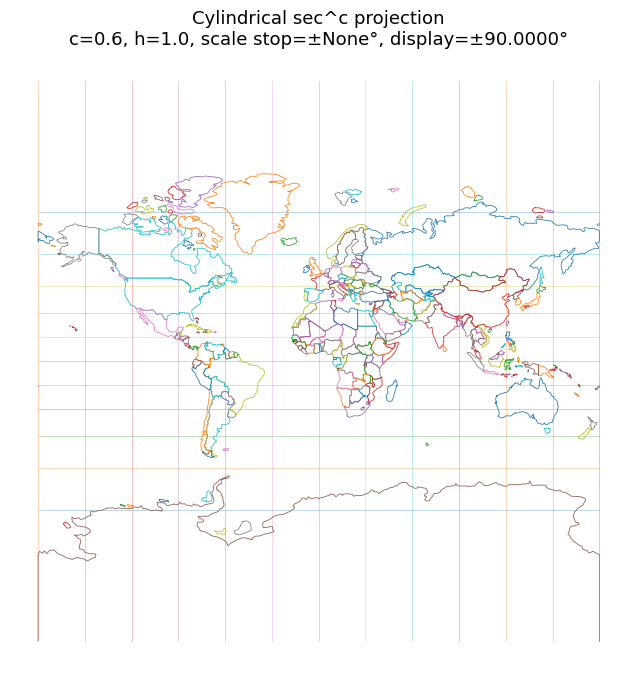

\mnt\data\c_cylindrical_c0.6_h1.0_stopNone.png
if stop latitude was 85
c-cylindrical projection
c                     = 0.6
h                     = 1.0
scale stop latitude   = 85

Map width             = 6.28318531
Original half-height  = 2.56899731
Original full height  = 5.13799461
Original aspect W/H   = 1.22288671

Maximum vertical scale= 4.32336990

h cutoff              = NO
Displayed latitude    = ±90 deg
Displayed aspect W/H  = 1.22288671


In [2]:
# ============================================================
# Example
# ============================================================

c = 0.6
h = 1.0

# After this latitude, sec^c enlargement stops increasing.
# None = original projection
stop_lat = None


projection_info(
    c=c,
    h=h,
    stop_lat=stop_lat
)

phi_cut, cropped = cutoff_latitude(
    c,
    h=h,
    stop_lat=stop_lat
)

lat_limit = np.rad2deg(phi_cut)


project = lambda lo, la: c_cylindrical(
    lo,
    la,
    c=c,
    h=h,
    stop_lat=stop_lat
)


fig, ax = plt.subplots(
    figsize=(14, 8)
)


title = (
    f"Cylindrical sec^c projection\n"
    f"c={c}, h={h}, "
    f"scale stop=±{stop_lat}°, "
    f"display=±{lat_limit:.4f}°"
)


draw_map(
    ax,
    project,
    title,
    lat_limit=lat_limit
)


out = Path(
    f"/mnt/data/"
    f"c_cylindrical_c{c}_h{h}_stop{stop_lat}.png"
)


fig.savefig(
    out,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print(out)

print("if stop latitude was 85")

projection_info(
    c=c,
    h=h,
    stop_lat=85
)

c-cylindrical projection
c                     = 0.6
h                     = 1.0
scale stop latitude   = 85

Map width             = 6.28318531
Original half-height  = 2.56899731
Original full height  = 5.13799461
Original aspect W/H   = 1.22288671

Maximum vertical scale= 4.32336990

h cutoff              = NO
Displayed latitude    = ±90 deg
Displayed aspect W/H  = 1.22288671


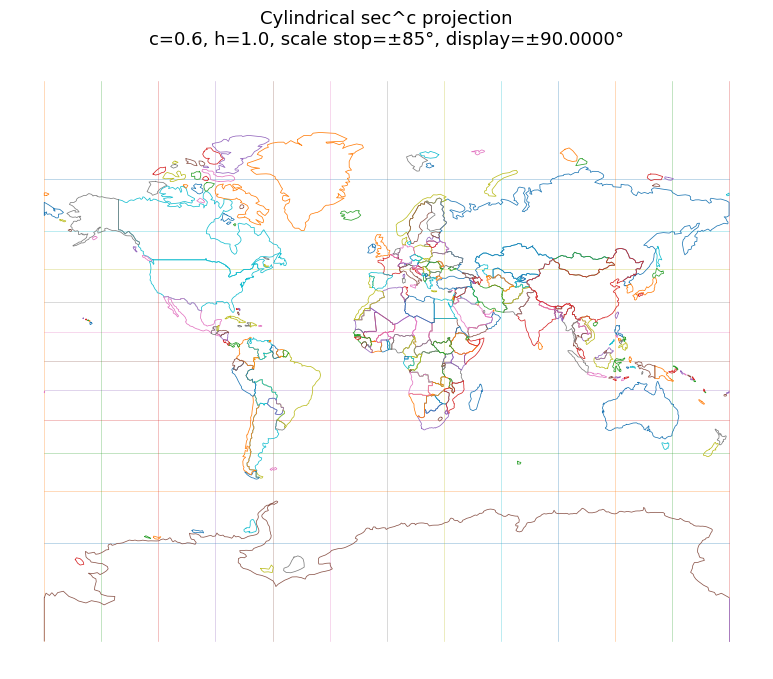

\mnt\data\c_cylindrical_c0.6_h1.0_stop85.png


In [3]:
stop_lat=85
projection_info(
    c=c,
    h=h,
    stop_lat=stop_lat
)

phi_cut, cropped = cutoff_latitude(
    c,
    h=h,
    stop_lat=85
)

lat_limit = np.rad2deg(phi_cut)


project = lambda lo, la: c_cylindrical(
    lo,
    la,
    c=c,
    h=h,
    stop_lat=stop_lat
)


fig, ax = plt.subplots(
    figsize=(14, 8)
)


title = (
    f"Cylindrical sec^c projection\n"
    f"c={c}, h={h}, "
    f"scale stop=±{stop_lat}°, "
    f"display=±{lat_limit:.4f}°"
)


draw_map(
    ax,
    project,
    title,
    lat_limit=lat_limit
)


out = Path(
    f"/mnt/data/"
    f"c_cylindrical_c{c}_h{h}_stop{stop_lat}.png"
)


fig.savefig(
    out,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print(out)

In [4]:
# ============================================================
# 9. Solve stop_lat from desired projected height
# ============================================================

from scipy.optimize import brentq


def solve_stop_lat_for_height(
    target_lat,
    target_y,
    c=0.6,
    verbose=True
):
    """
    Find stop_lat [degrees] such that a specified latitude
    is projected to the desired |y| coordinate.

    Parameters
    ----------
    target_lat : float
        Target latitude in degrees.
        Example: 90 means the pole.

    target_y : float
        Desired projected distance from the equator.
        Must be positive.

    c : float
        Exponent in dy/dphi = sec(phi)^c.

    Returns
    -------
    stop_lat : float
        Latitude [degrees] where vertical scale growth
        should stop.

    Equation
    --------
    For stop_lat = s < target_lat:

        y_target
        =
        integral_0^s sec(t)^c dt
        + sec(s)^c * (phi_target - s)

    """

    if c < 0:
        raise ValueError("c must be >= 0")

    phi_target = np.deg2rad(abs(target_lat))
    target_y = abs(float(target_y))

    if not (0 < phi_target <= np.pi / 2):
        raise ValueError(
            "target_lat must satisfy 0 < |target_lat| <= 90"
        )

    # --------------------------------------------------------
    # Minimum possible height:
    #
    # stop_lat = 0
    # scale is frozen at 1 immediately
    #
    # y = phi_target
    # --------------------------------------------------------

    y_min = phi_target

    # --------------------------------------------------------
    # Maximum possible height:
    #
    # no scale cap before target latitude
    # --------------------------------------------------------

    if c == 0:

        y_max = phi_target

    elif c == 1 and np.isclose(
        phi_target,
        np.pi / 2
    ):

        y_max = np.inf

    else:

        y_max = abs(
            y_scalar(
                phi_target,
                c,
                stop_lat=None
            )
        )

    # --------------------------------------------------------
    # Check whether requested height is achievable
    # --------------------------------------------------------

    tol = 1e-10

    if target_y < y_min - tol:

        raise ValueError(
            f"target_y={target_y:.8f} is too small.\n"
            f"Minimum possible value at "
            f"{abs(target_lat):.8f}° is "
            f"{y_min:.8f}."
        )

    if np.isfinite(y_max) and target_y > y_max + tol:

        raise ValueError(
            f"target_y={target_y:.8f} is too large.\n"
            f"Maximum uncapped value at "
            f"{abs(target_lat):.8f}° is "
            f"{y_max:.8f}."
        )

    # c = 0 has no scale growth at all
    if c == 0:

        if np.isclose(
            target_y,
            phi_target,
            atol=tol
        ):

            if verbose:
                print(
                    "c = 0: scale is already constant."
                )

            return 0.0

        raise ValueError(
            "For c=0, projected height cannot be changed "
            "by stop_lat."
        )

    # --------------------------------------------------------
    # target_y = minimum
    # -> stop immediately at equator
    # --------------------------------------------------------

    if np.isclose(
        target_y,
        y_min,
        atol=tol
    ):

        result = 0.0

        if verbose:
            print(
                f"stop_lat = {result:.10f}°"
            )

        return result

    # --------------------------------------------------------
    # target_y = uncapped height
    #
    # No cap is required before target latitude.
    # Return target latitude.
    # --------------------------------------------------------

    if (
        np.isfinite(y_max)
        and np.isclose(
            target_y,
            y_max,
            atol=tol
        )
    ):

        result = abs(target_lat)

        if verbose:
            print(
                f"stop_lat = {result:.10f}°"
            )
            print(
                "The requested height equals the "
                "uncapped projection."
            )

        return result

    # --------------------------------------------------------
    # Equation to solve:
    #
    # y(phi_target; stop_lat) = target_y
    # --------------------------------------------------------

    def equation(stop_deg):

        y = y_scalar(
            phi_target,
            c,
            stop_lat=stop_deg
        )

        return abs(y) - target_y

    # Don't evaluate exactly at 90 degrees.
    upper_deg = min(
        abs(target_lat),
        90.0 - 1e-10
    )

    stop_lat = brentq(
        equation,
        0.0,
        upper_deg,
        xtol=1e-12,
        rtol=1e-12
    )

    # --------------------------------------------------------
    # Verify
    # --------------------------------------------------------

    obtained_y = abs(
        y_scalar(
            phi_target,
            c,
            stop_lat=stop_lat
        )
    )

    scale_cap = (
        np.cos(
            np.deg2rad(stop_lat)
        ) ** (-c)
    )

    if verbose:

        print("=" * 60)
        print("stop_lat solver")
        print("=" * 60)

        print(
            f"c                       = {c}"
        )

        print(
            f"Target latitude         = "
            f"{abs(target_lat):.10f}°"
        )

        print(
            f"Desired y               = "
            f"{target_y:.10f}"
        )

        print(
            f"Solved stop_lat         = "
            f"{stop_lat:.10f}°"
        )

        print(
            f"Maximum vertical scale  = "
            f"{scale_cap:.10f}"
        )

        print(
            f"Obtained y              = "
            f"{obtained_y:.10f}"
        )

        print(
            f"Error                    = "
            f"{obtained_y-target_y:+.3e}"
        )

        print("=" * 60)

    return stop_lat

In [5]:
c = 1

stop_lat = solve_stop_lat_for_height(
    target_lat=90,
    target_y=np.pi,
    c=c
)
stop_lat

stop_lat solver
c                       = 1
Target latitude         = 90.0000000000°
Desired y               = 3.1415926536
Solved stop_lat         = 76.4759452094°
Maximum vertical scale  = 4.2761800203
Obtained y              = 3.1415926536
Error                    = -5.214e-13


76.47594520939936

Compact Mercator projection
c-cylindrical projection
c                     = 1
h                     = 1
scale stop latitude   = 76.47594520939936

Map width             = 6.28318531
Original half-height  = 3.14159265
Original full height  = 6.28318531
Original aspect W/H   = 1.00000000

Maximum vertical scale= 4.27618002

h cutoff              = NO
Displayed latitude    = ±90 deg
Displayed aspect W/H  = 1.00000000


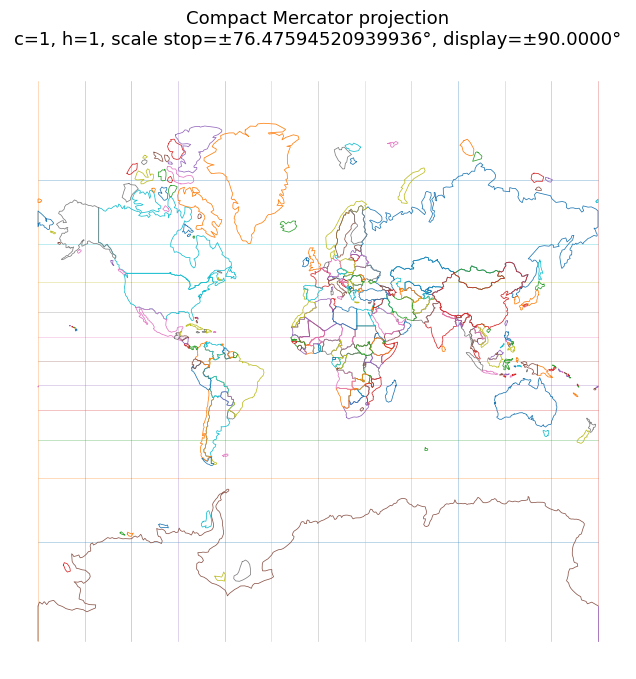

\mnt\data\c_cylindrical_c1_h1_stop76.47594520939936.png


In [6]:
print("Compact Mercator projection")
# ============================================================
# Example
# ============================================================

c = 1
h = 1

# After this latitude, sec^c enlargement stops increasing.
# None = original projection
stop_lat = stop_lat


projection_info(
    c=c,
    h=h,
    stop_lat=stop_lat
)

phi_cut, cropped = cutoff_latitude(
    c,
    h=h,
    stop_lat=stop_lat
)

lat_limit = np.rad2deg(phi_cut)


project = lambda lo, la: c_cylindrical(
    lo,
    la,
    c=c,
    h=h,
    stop_lat=stop_lat
)


fig, ax = plt.subplots(
    figsize=(14, 8)
)


title = (
    f"Compact Mercator projection\n"
    f"c={c}, h={h}, "
    f"scale stop=±{stop_lat}°, "
    f"display=±{lat_limit:.4f}°"
)


draw_map(
    ax,
    project,
    title,
    lat_limit=lat_limit
)


out = Path(
    f"/mnt/data/"
    f"c_cylindrical_c{c}_h{h}_stop{stop_lat}.png"
)


fig.savefig(
    out,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print(out)
